# Phase 2: Exploratory Data Analysis (EDA)
**Project: Multivariate Electricity Demand Forecasting Using Weather and Calendar Effects**

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the 2022 Indian electricity load and weather dataset.

**Goals of this EDA:**
1. **Time Series Visualization:** Understand trend and seasonality (weekly, monthly).
2. **Weather Correlations:** Determine how temperature and precipitation impact load.
3. **Stationarity & Autocorrelation:** Check for stationarity (ADF/KPSS) and identify AR/MA lags (ACF/PACF).
4. **Data Quality Profile:** Assess missing values from raw extraction and the impact of interpolation.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# Paths
BASE_DIR = '../'
DATA_DIR = f'{BASE_DIR}data/'


## 2.1 Load Datasets

In [12]:
# Load Univariate Data
df_uni = pd.read_csv(f'{DATA_DIR}processed/load_data_2022_final.csv', parse_dates=['date'])
df_uni = df_uni.set_index('date')

# Load Multivariate Data (Load + Weather + Calendar Features)
df_multi = pd.read_csv(f'{DATA_DIR}processed/load_weather_2022_features.csv', parse_dates=['date'])
df_multi = df_multi.set_index('date')

print("Univariate Shape:", df_uni.shape)
print("Multivariate Shape:", df_multi.shape)
display(df_multi.head(3))


Univariate Shape: (365, 1)
Multivariate Shape: (335, 20)


,load,temp_max,temp_min,temp_avg,temp_range,precipitation,wind_speed,day_of_week,day_of_month,month,is_weekend,month_sin,month_cos,day_sin,day_cos,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7
date,,,,,,,,,,,,,,,,,,,,
2022-01-31,192078.0,28.9,21.8,25.35,7.1,0.0,15.9,0,31,1,0,0.500000,0.866025,0.000000,1.000000,184867.0,187245.0,178873.0,187860.928571,3750.257863
2022-02-01,192024.0,28.1,21.1,24.60,7.0,0.0,13.1,1,1,2,0,0.866025,0.500000,0.781831,0.623490,192078.0,188856.0,179232.5,188313.500000,4068.043234
2022-02-02,192470.0,27.9,19.5,23.70,8.4,0.0,13.0,2,2,2,0,0.866025,0.500000,0.974928,-0.222521,192024.0,181462.0,179592.0,189886.071429,2952.863814


## 2.2 Time Series Visualizations
Let's analyze the daily peak load patterns over the year.

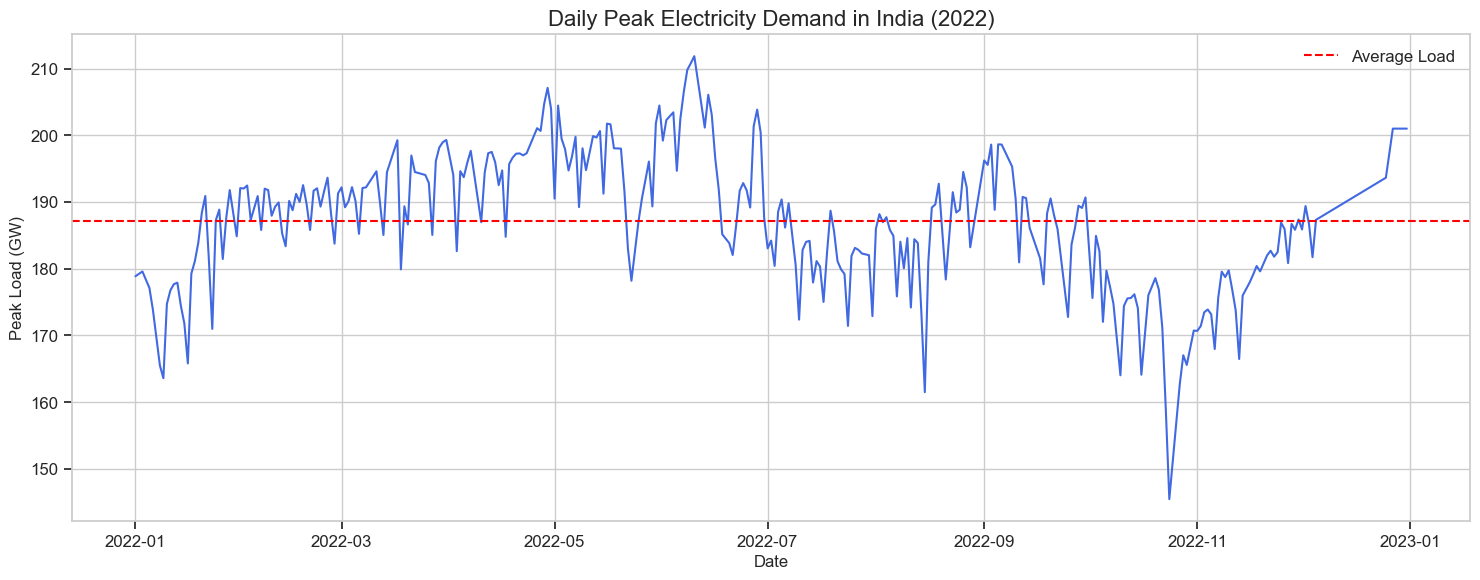

In [13]:
# Plot continuous full-year daily load
plt.figure(figsize=(15, 6))
plt.plot(df_uni.index, df_uni['load'] / 1000, color='royalblue', linewidth=1.5)
plt.title('Daily Peak Electricity Demand in India (2022)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Peak Load (GW)', fontsize=12)
plt.axhline(df_uni['load'].mean() / 1000, color='red', linestyle='--', label='Average Load')
plt.legend()
plt.tight_layout()
plt.show()


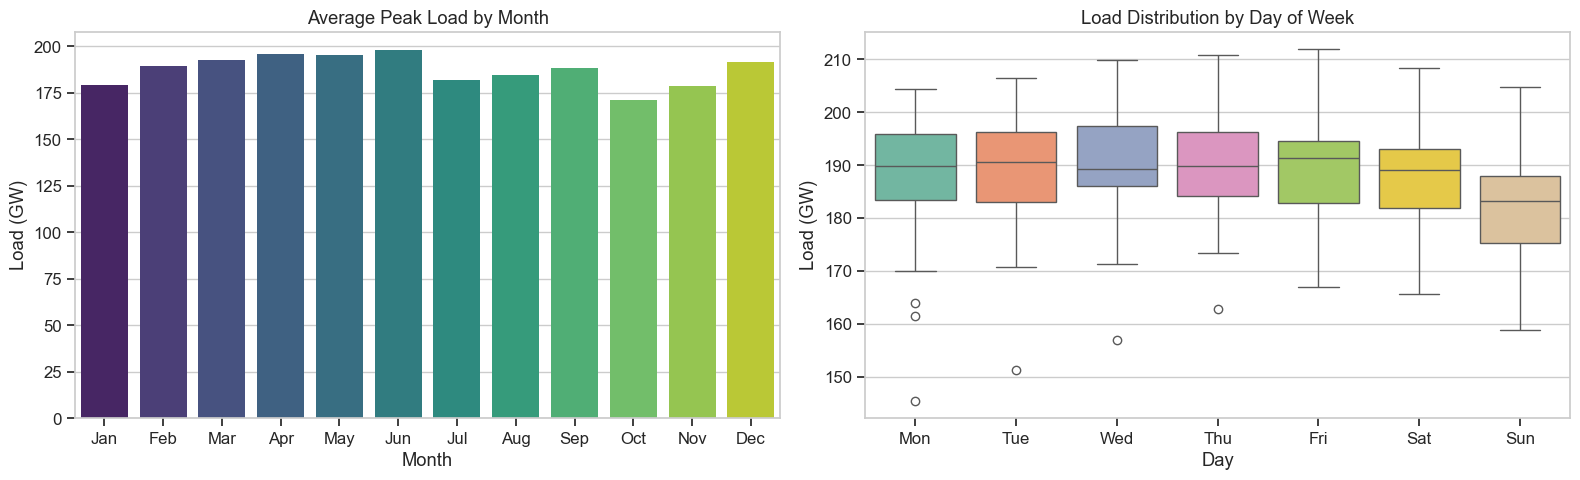

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly Average Load
monthly_load = df_uni.resample('ME').mean()
sns.barplot(x=monthly_load.index.month_name().str[:3], y=monthly_load['load'] / 1000, ax=axes[0], palette='viridis')
axes[0].set_title('Average Peak Load by Month')
axes[0].set_ylabel('Load (GW)')
axes[0].set_xlabel('Month')

# Weekly Pattern (Day of Week)
day_mapping = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df_multi['day_name'] = df_multi['day_of_week'].map(day_mapping)
sns.boxplot(x='day_name', y=df_multi['load'] / 1000, data=df_multi, order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], ax=axes[1], palette='Set2')
axes[1].set_title('Load Distribution by Day of Week')
axes[1].set_ylabel('Load (GW)')
axes[1].set_xlabel('Day')

plt.tight_layout()
plt.show()

# Drop temporary column
df_multi = df_multi.drop(columns=['day_name'])


## 2.3 Weather Correlations
How do temperature and wind/rain influence the electricity demand?

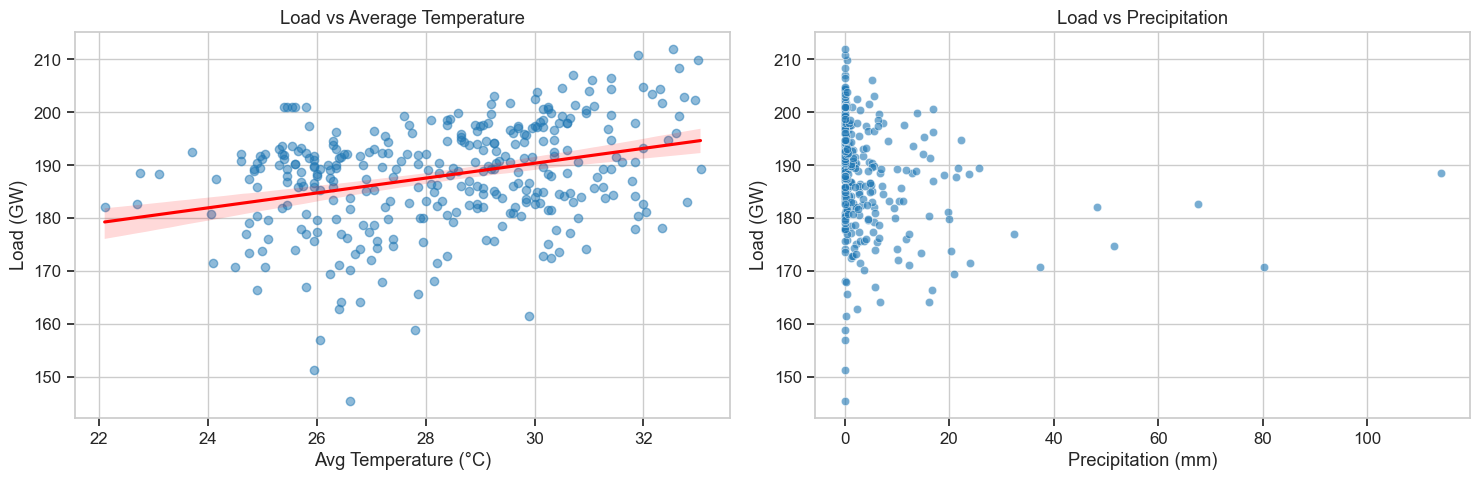

In [15]:
# Scatter: Load vs Temperature
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(x='temp_avg', y=df_multi['load']/1000, data=df_multi, ax=axes[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Load vs Average Temperature')
axes[0].set_xlabel('Avg Temperature (°C)')
axes[0].set_ylabel('Load (GW)')

# Scatter: Load vs Precipitation
sns.scatterplot(x='precipitation', y=df_multi['load']/1000, data=df_multi, ax=axes[1], alpha=0.6)
axes[1].set_title('Load vs Precipitation')
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_ylabel('Load (GW)')

plt.tight_layout()
plt.show()


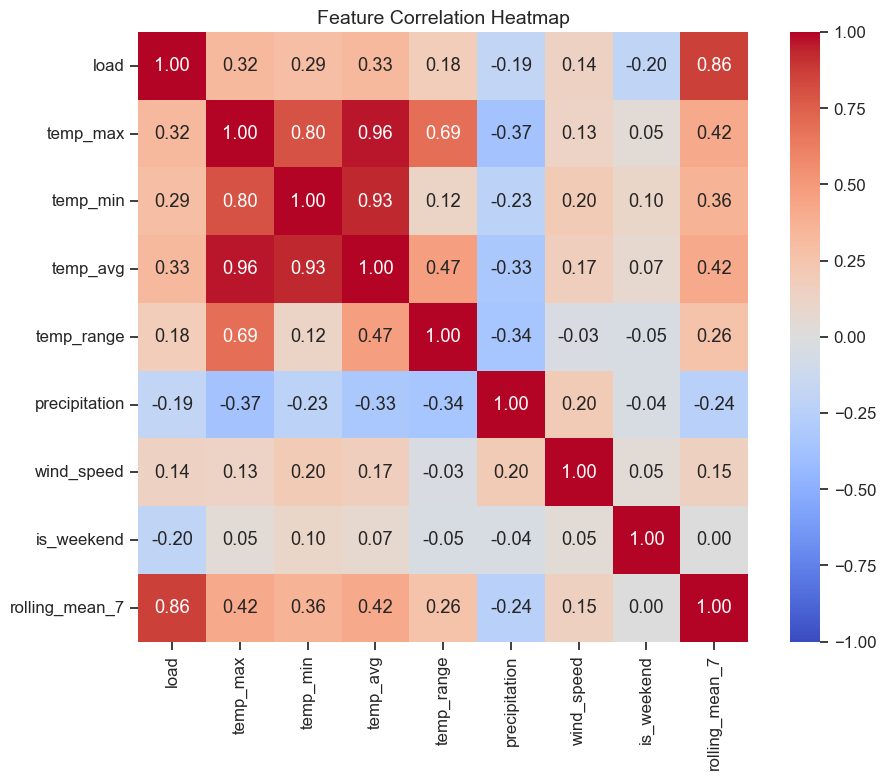

In [16]:
# Correlation Heatmap for Model Variables
corr_vars = ['load', 'temp_max', 'temp_min', 'temp_avg', 'temp_range', 'precipitation', 'wind_speed', 'is_weekend', 'rolling_mean_7']
corr_matrix = df_multi[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


## 2.4 Stationarity Checks
Checking if the time series is stationary (constant mean and variance over time) using Augmented Dickey-Fuller (ADF) and KPSS tests.
* **ADF Null Hypothesis:** Series is non-stationary. (p < 0.05 implies stationarity)
* **KPSS Null Hypothesis:** Series is stationary. (p < 0.05 implies non-stationarity)

In [17]:
def adf_kpss_test(timeseries):
    print('--- Augmented Dickey-Fuller (ADF) Test ---')
    adf_result = adfuller(timeseries, autolag='AIC')
    print(f'ADF Statistic: {adf_result[0]:.4f}')
    print(f'p-value: {adf_result[1]:.4f}')
    if adf_result[1] <= 0.05:
        print("=> Reject Null: Series is Stationary.\n")
    else:
        print("=> Fail to Reject Null: Series is NON-Stationary.\n")
        
    print('--- KPSS Test ---')
    kpss_result = kpss(timeseries, regression='c', nlags="auto")
    print(f'KPSS Statistic: {kpss_result[0]:.4f}')
    print(f'p-value: {kpss_result[1]:.4f}')
    if kpss_result[1] <= 0.05:
        print("=> Reject Null: Series is NON-Stationary.")
    else:
        print("=> Fail to Reject Null: Series is Stationary.")

# Run tests
adf_kpss_test(df_uni['load'])


--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -2.2983
p-value: 0.1725
=> Fail to Reject Null: Series is NON-Stationary.

--- KPSS Test ---
KPSS Statistic: 0.5991
p-value: 0.0227
=> Reject Null: Series is NON-Stationary.


## 2.5 Seasonality & Decomposition
Breaking the series into Trend, Seasonal, and Residual components. Examining Auto-correlation (ACF) to identify AR lags, and Partial Auto-correlation (PACF) to identify MA lags for SARIMAX.

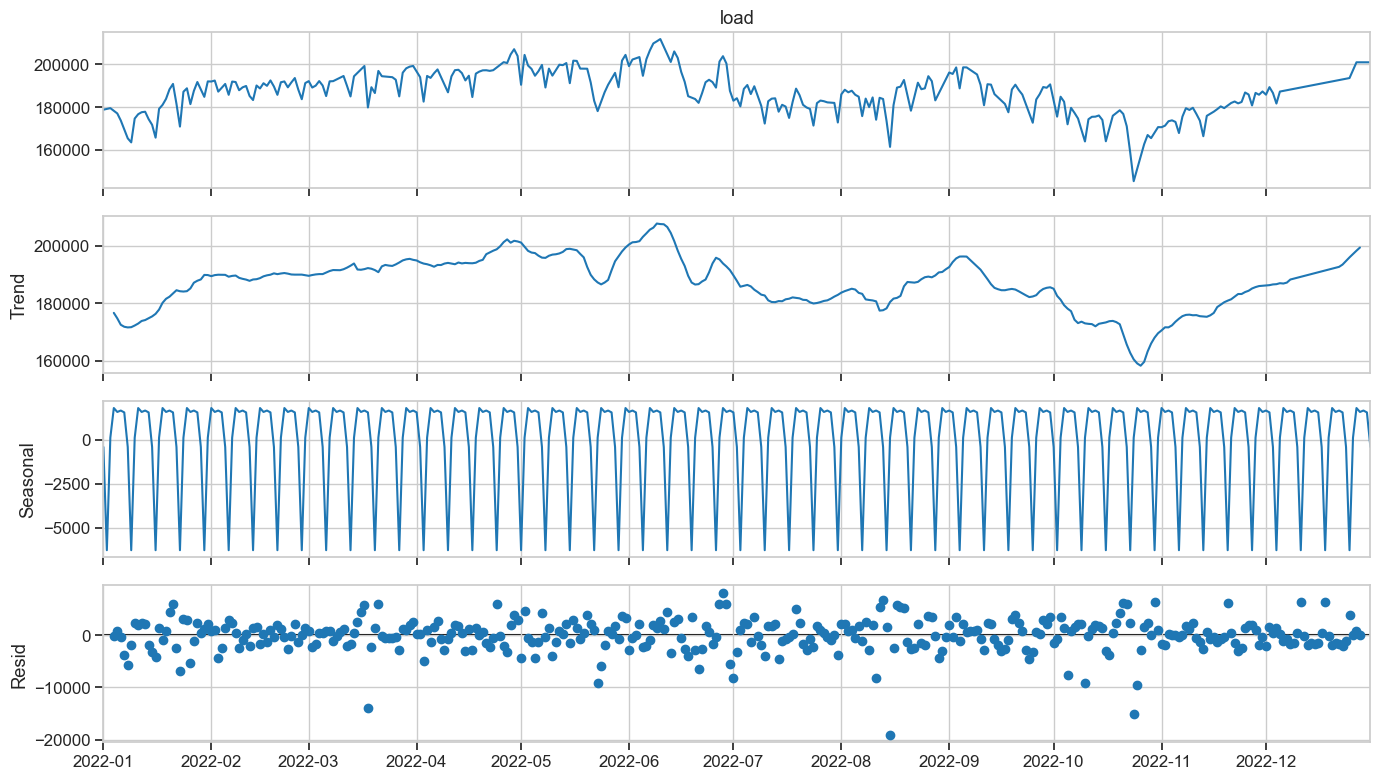

In [18]:
# STL Decomposition (Assuming 7-day weekly seasonality for the period)
decomposition = seasonal_decompose(df_uni['load'], model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()


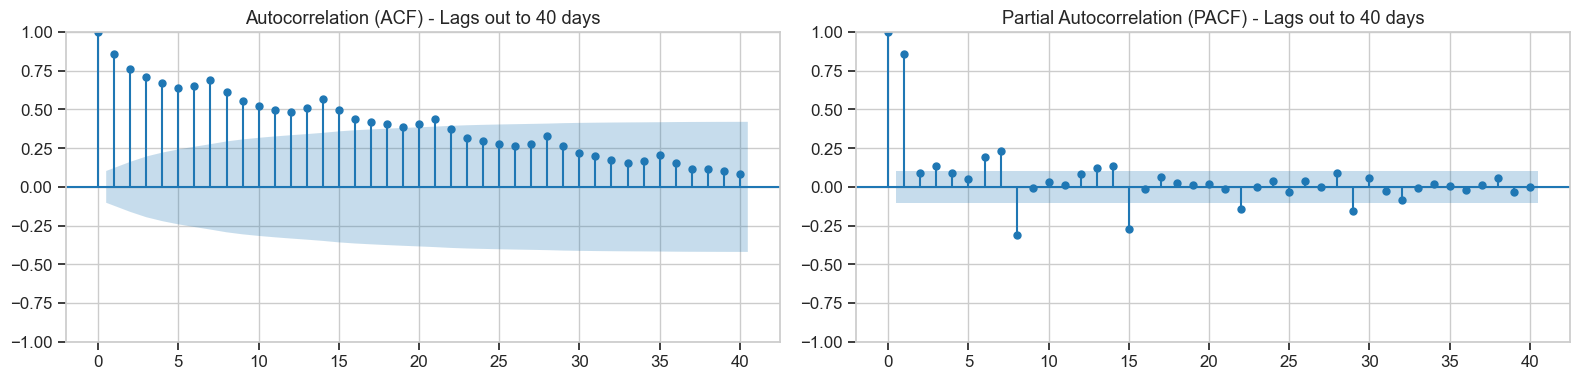

In [19]:
# ACF and PACF Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_uni['load'], lags=40, ax=axes[0], title='Autocorrelation (ACF) - Lags out to 40 days')
plot_pacf(df_uni['load'], lags=40, ax=axes[1], title='Partial Autocorrelation (PACF) - Lags out to 40 days')
plt.tight_layout()
plt.show()


## 2.6 Missing Data Profile
Looking at the fraction of missing PDF reports (which we handled via linear interpolation in Phase 1).

Total days in year : 365
Total PDFs found   : 298
Missing days       : 67
Missing %          : 18.4%


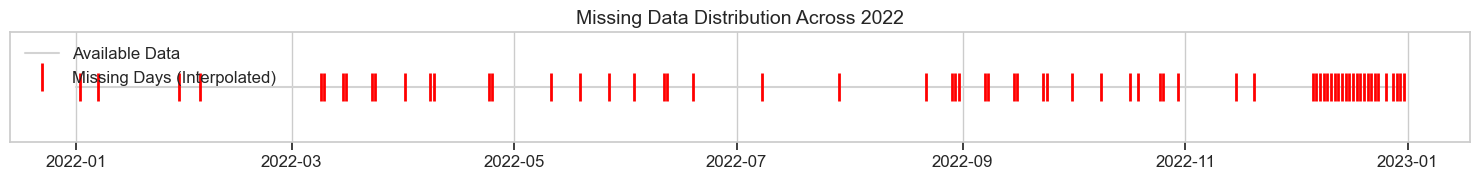

In [20]:
raw_csv = f'{DATA_DIR}processed/load_data_2022.csv'
if os.path.exists(raw_csv):
    df_raw = pd.read_csv(raw_csv, parse_dates=['date'])
    # Identify missing days
    full_dates = pd.date_range(start="2022-01-01", end="2022-12-31")
    raw_dates = pd.DatetimeIndex(df_raw['date'])
    missing_dates = full_dates.difference(raw_dates)
    
    print(f"Total days in year : {len(full_dates)}")
    print(f"Total PDFs found   : {len(raw_dates)}")
    print(f"Missing days       : {len(missing_dates)}")
    print(f"Missing %          : {(len(missing_dates)/len(full_dates))*100:.1f}%")
    
    # Plot missing days as a rug plot
    plt.figure(figsize=(15, 2))
    plt.plot(full_dates, np.ones(len(full_dates)), color='lightgrey', label='Available Data')
    plt.plot(missing_dates, np.ones(len(missing_dates)), 'r|', markersize=20, markeredgewidth=2, label='Missing Days (Interpolated)')
    plt.title('Missing Data Distribution Across 2022', fontsize=14)
    plt.legend()
    plt.yticks([])
    plt.tight_layout()
    plt.show()
else:
    print("Raw CSV not found for comparison.")
